In [1]:
# DEPENDENCIES

import sys
sys.path.insert(0, '../../..')
from dependencies import *
from constants import *
from paths import *
import helper_functions

# Within-dataset Generalisation

In [2]:
# SET-UP
SUBJECTS         = helper_functions.fuglsang_get_subjects()
test_percent     = 0.3
n_test           = int(len(SUBJECTS) * test_percent)
training_subjects = SUBJECTS[:-n_test]
testing_subjects  = SUBJECTS[-n_test:]
print("Training subjects: ", training_subjects)
print("Testing subjects: ", testing_subjects)

Training subjects:  ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12', 'S13']
Testing subjects:  ['S14', 'S15', 'S16', 'S17', 'S18']


# Visual inspection

  ✓ S1
  ✓ S2
  ✓ S3
  ✓ S4
  ✓ S5
  ✓ S6
  ✓ S7
  ✓ S8
  ✓ S9
  ✓ S10
  ✓ S11
  ✓ S12
  ✓ S13
  ✓ S14
  ✓ S15
  ✓ S16
  ✓ S17
  ✓ S18

Loaded: 18 subjects | Skipped: 0 subjects


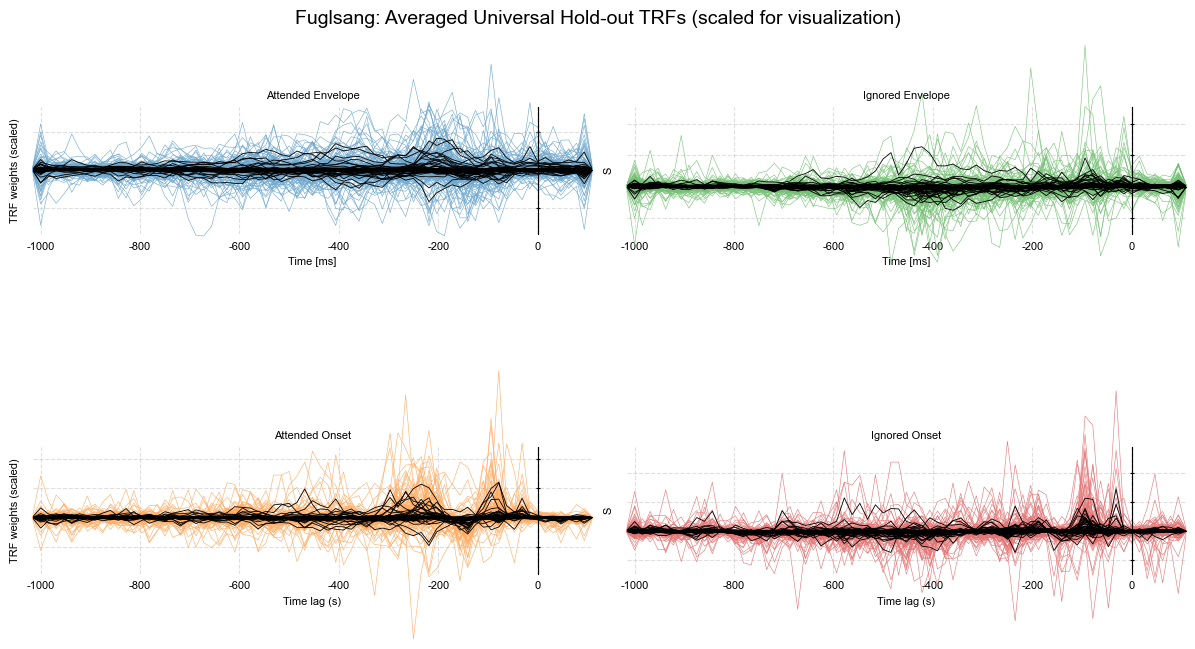

In [3]:
helper_functions.set_plot_style()

# ─────────────────────────────────────────────
# Define models and visual properties
# ─────────────────────────────────────────────

trf_types = [
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD),
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD),
]

titles = {
    helper_functions.get_trf_model_name(DATASET_TYPE.FUGLSANG, *t): f"{'Attended' if t[1] == ATTENTION_TYPE.ATTENDED else 'Ignored'} {'Envelope' if t[0] == PREDICTOR_TYPE.ENVELOPE else 'Onset'}"
    for t in trf_types
}

colors = {
    helper_functions.get_trf_model_name(DATASET_TYPE.FUGLSANG, *trf_types[0]): 'tab:blue',
    helper_functions.get_trf_model_name(DATASET_TYPE.FUGLSANG, *trf_types[1]): 'tab:green',
    helper_functions.get_trf_model_name(DATASET_TYPE.FUGLSANG, *trf_types[2]): 'tab:orange',
    helper_functions.get_trf_model_name(DATASET_TYPE.FUGLSANG, *trf_types[3]): 'tab:red',
}

# ─────────────────────────────────────────────
# Load individual TRFs
# ─────────────────────────────────────────────

individual_trf_data, _ = helper_functions.load_trfs(
    DATASET_TYPE.FUGLSANG, SUBJECTS, trf_types, trf_dir=FUGLSANG_TRF_SELF_DIR
)

# ─────────────────────────────────────────────
# Helper
# ─────────────────────────────────────────────

def zscore(h):
    return (h - h.mean()) / h.std()

def prepare_trf(trf):
    return zscore(trf.h_scaled)

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
axes = axes.flatten()

for idx, trf_type in enumerate(trf_types):
    ax          = axes[idx]
    model_name  = helper_functions.get_trf_model_name(DATASET_TYPE.FUGLSANG, *trf_type)
    base_color  = colors[model_name]
    light_color = helper_functions.lighten_color(base_color, amount=0.35)

    # Load universal TRF
    universal_name = helper_functions.get_trf_model_name(
        DATASET_TYPE.FUGLSANG, *trf_type, GENERALISATION_TYPE.AVERAGE
    )
    trf_univ_plot = prepare_trf(
        eelbrain.load.unpickle(FUGLSANG_TRF_GENERAL_DIR / f'hold_out_{universal_name}.pickle')
    )

    # Individual TRFs (faded)
    for trf in individual_trf_data[model_name]:
        eelbrain.plot.Butterfly(
            prepare_trf(trf),
            axes=ax, color=light_color, linewidth=0.4, frame='t'
        )

    # Universal TRF (bold)
    eelbrain.plot.Butterfly(
        trf_univ_plot, axes=ax, color='black', linewidth=0.6
    )

    # Set ylim AFTER all drawing, based on universal TRF
    y_min, y_max = trf_univ_plot.x.min(), trf_univ_plot.x.max()
    ax.set_ylim(y_min * 2, y_max * 2)

    ax.set_title(titles[model_name])
    ax.axhline(0, linestyle='--', color='black', linewidth=0.8)
    ax.axvline(0, linestyle='--', color='black', linewidth=0.8)
    ax.grid(True, linestyle='--', alpha=0.4)

axes[2].set_xlabel('Time lag (s)')
axes[3].set_xlabel('Time lag (s)')
axes[0].set_ylabel('TRF weights (scaled)')
axes[2].set_ylabel('TRF weights (scaled)')

for ax in axes:
    ax.set_yticklabels([])

fig.suptitle('Fuglsang: Averaged Universal Hold-out TRFs (scaled for visualization)', fontsize=14, y=0.9)
plt.tight_layout()
fig.savefig(BEYOND_FIGURES_DIR / 'universal-vs-all-trfs.png', dpi=150, bbox_inches='tight')
plt.show()

# Hold-out results

## Figure 2 — Held-out subjects: r_attended vs r_ignored (scatter)

In [4]:
# ─────────────────────────────────────────────
# Run classifier
# ─────────────────────────────────────────────
acc_env,   decisions_env,   r_atts_env,   r_igns_env   = helper_functions.aad_classifier(PREDICTOR_TYPE.ENVELOPE, testing_subjects, generalised=GENERALISATION_TYPE.AVERAGE, cv=CROSS_VALIDATION_TYPE.HOLD_OUT, aad_type=AAD_APPROACH.DOUBLE)
acc_onset, decisions_onset, r_atts_onset, r_igns_onset = helper_functions.aad_classifier(PREDICTOR_TYPE.ENVELOPE_ONSET, testing_subjects, generalised=GENERALISATION_TYPE.AVERAGE, cv=CROSS_VALIDATION_TYPE.HOLD_OUT, aad_type=AAD_APPROACH.DOUBLE)


S14: r_att=0.175, r_ign=0.068
S15: r_att=0.202, r_ign=0.077
S16: r_att=0.096, r_ign=0.086
S17: r_att=0.088, r_ign=0.010
S18: r_att=0.148, r_ign=0.043

✅ Classification rate (PREDICTOR_TYPE.ENVELOPE): 100.00%

────────────────────────────────────────────────────────────

S14: r_att=0.077, r_ign=0.033
S15: r_att=0.087, r_ign=0.035
S16: r_att=0.051, r_ign=0.034
S17: r_att=0.035, r_ign=0.000
S18: r_att=0.059, r_ign=0.023

✅ Classification rate (PREDICTOR_TYPE.ENVELOPE_ONSET): 100.00%

────────────────────────────────────────────────────────────



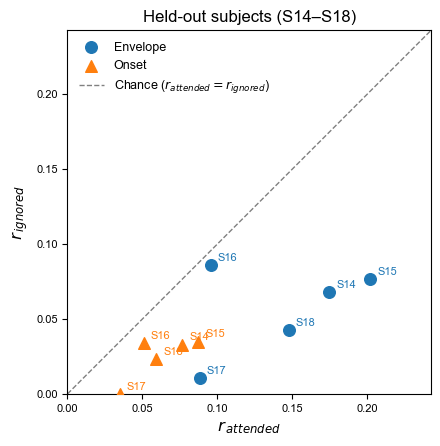

In [5]:
# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────

helper_functions.set_plot_style()

color_env   = 'tab:blue'
color_onset = 'tab:orange'
subjects    = list(r_atts_env.keys())

env_att   = [r_atts_env[s]   for s in subjects]
env_ign   = [r_igns_env[s]   for s in subjects]
onset_att = [r_atts_onset[s] for s in subjects]
onset_ign = [r_igns_onset[s] for s in subjects]

fig, ax = plt.subplots(figsize=(4.5, 4.5))

ax.scatter(env_att,   env_ign,   color=color_env,   marker='o', s=70, zorder=4, label='Envelope')
ax.scatter(onset_att, onset_ign, color=color_onset, marker='^', s=70, zorder=4, label='Onset')

for s, xi, yi in zip(subjects, env_att, env_ign):
    ax.annotate(s, (xi, yi), textcoords='offset points', xytext=(5, 3), fontsize=8, color=color_env)
for s, xi, yi in zip(subjects, onset_att, onset_ign):
    ax.annotate(s, (xi, yi), textcoords='offset points', xytext=(5, 3), fontsize=8, color=color_onset)

lim = max(env_att + env_ign + onset_att + onset_ign) * 1.2
ax.plot([0, lim], [0, lim], color='gray', linestyle='--', linewidth=1,
        label=r'Chance ($r_{attended} = r_{ignored}$)', zorder=2)

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel(r'$r_{\,attended}$', fontsize=12)
ax.set_ylabel(r'$r_{\,ignored}$', fontsize=12)
ax.set_title(f'Held-out subjects ({testing_subjects[0]}–{testing_subjects[-1]})', fontsize=12)
ax.legend(frameon=False, fontsize=9)
ax.set_aspect('equal')

fig.tight_layout()
fig.savefig(BEYOND_FIGURES_DIR / 'heldout-scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Leave-one-out results

## Figure 3 — LOOCV group correlations (bar chart)

In [6]:
# ─────────────────────────────────────────────
# Run classifiers
# ─────────────────────────────────────────────

acc_env,   decisions_env,   r_atts_env,   r_igns_env   = helper_functions.aad_classifier(
    PREDICTOR_TYPE.ENVELOPE, SUBJECTS,
    generalised=GENERALISATION_TYPE.AVERAGE, cv=CROSS_VALIDATION_TYPE.LOO, aad_type=AAD_APPROACH.DOUBLE
)
acc_onset, decisions_onset, r_atts_onset, r_igns_onset = helper_functions.aad_classifier(
    PREDICTOR_TYPE.ENVELOPE_ONSET, SUBJECTS,
    generalised=GENERALISATION_TYPE.AVERAGE, cv=CROSS_VALIDATION_TYPE.LOO, aad_type=AAD_APPROACH.DOUBLE
)

S1: r_att=0.044, r_ign=0.030
S2: r_att=0.137, r_ign=0.083
S3: r_att=0.080, r_ign=0.045
S4: r_att=0.148, r_ign=0.090
S5: r_att=0.117, r_ign=0.045
S6: r_att=0.055, r_ign=0.020
S7: r_att=0.222, r_ign=0.076
S8: r_att=0.099, r_ign=0.045
S9: r_att=0.110, r_ign=0.055
S10: r_att=0.091, r_ign=0.026
S11: r_att=0.005, r_ign=0.005
S12: r_att=0.064, r_ign=0.067
S13: r_att=0.134, r_ign=0.070
S14: r_att=0.175, r_ign=0.070
S15: r_att=0.202, r_ign=0.077
S16: r_att=0.091, r_ign=0.086
S17: r_att=0.083, r_ign=0.007
S18: r_att=0.141, r_ign=0.043

✅ Classification rate (PREDICTOR_TYPE.ENVELOPE): 88.89%

────────────────────────────────────────────────────────────

S1: r_att=0.023, r_ign=0.016
S2: r_att=0.068, r_ign=0.040
S3: r_att=0.035, r_ign=0.020
S4: r_att=0.076, r_ign=0.036
S5: r_att=0.044, r_ign=0.018
S6: r_att=0.026, r_ign=0.015
S7: r_att=0.087, r_ign=0.027
S8: r_att=0.052, r_ign=0.022
S9: r_att=0.052, r_ign=0.027
S10: r_att=0.041, r_ign=0.017
S11: r_att=0.004, r_ign=0.000
S12: r_att=0.035, r_ign=0.03

Attended envelope mean:  0.11093679233259382
Attended envelope std:  0.053685243018518174

Ignored envelope mean:  0.052154870538424644
Ignored envelope std:  0.026030069306443783

Attended onset mean:  0.050136889287341196
Attended onset std:  0.022235177244115684

Ignored onset mean:  0.023536076298988597
Ignored onset std:  0.011052413477231706


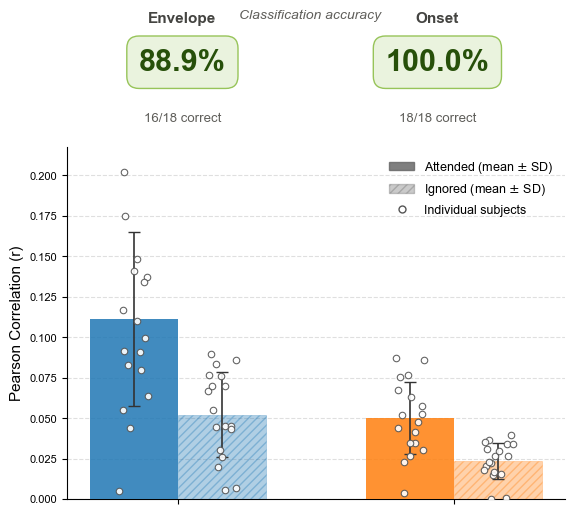

In [7]:
# ─────────────────────────────────────────────
# Prepare data for plot
# ─────────────────────────────────────────────

att_vals_all = [np.array(list(r_atts_env.values())),   np.array(list(r_atts_onset.values()))]
ign_vals_all = [np.array(list(r_igns_env.values())),   np.array(list(r_igns_onset.values()))]
att_means    = [v.mean() for v in att_vals_all]
ign_means    = [v.mean() for v in ign_vals_all]
att_sds      = [v.std()  for v in att_vals_all]
ign_sds      = [v.std()  for v in ign_vals_all]


print("Attended envelope mean: ", att_means[0])
print("Attended envelope std: ", att_sds[0])
print("")
print("Ignored envelope mean: ", ign_means[0])
print("Ignored envelope std: ", ign_sds[0])
print("")
print("Attended onset mean: ", att_means[1])
print("Attended onset std: ", att_sds[1])
print("")
print("Ignored onset mean: ", ign_means[1])
print("Ignored onset std: ", ign_sds[1])

correct_env   = sum(decisions_env.values())
correct_onset = sum(decisions_onset.values())
total         = len(SUBJECTS)

predictor_labels = ['Envelope', 'Onset']
colors           = ['tab:blue', 'tab:orange']
x                = np.arange(len(predictor_labels))
width            = 0.32

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────

helper_functions.set_plot_style()

fig = plt.figure(figsize=(6, 5.5))

# ── Top: accuracy badges ──────────────────────────────────────────────────────
ax_top = fig.add_axes([0.1, 0.75, 0.85, 0.22])
ax_top.axis('off')
ax_top.set_xlim(0, 1)
ax_top.set_ylim(0, 1)

ax_top.text(0.5, 1.0, 'Classification accuracy',
            ha='center', va='top', fontsize=10,
            color='#5F5E5A', fontstyle='italic',
            transform=ax_top.transAxes)

for i, (pred, correct) in enumerate(zip(predictor_labels, [correct_env, correct_onset])):
    pct  = correct / total * 100
    xpos = 0.25 + i * 0.5

    ax_top.text(xpos, 0.98, pred,
                ha='center', va='top', fontsize=11,
                color='#444441', fontweight='bold')
    ax_top.text(xpos, 0.68, f'{pct:.1f}%',
                ha='center', va='top', fontsize=22, fontweight='bold',
                color='#27500A',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#EAF3DE',
                          edgecolor='#97C459', linewidth=1))
    ax_top.text(xpos, 0.05, f'{correct}/{total} correct',
                ha='center', va='bottom', fontsize=9.5,
                color='#5F5E5A')

# ── Bottom: bar + dot plot ────────────────────────────────────────────────────
ax = fig.add_axes([0.12, 0.08, 0.83, 0.64])

for i, (col, att_m, att_s, ign_m, ign_s) in enumerate(
        zip(colors, att_means, att_sds, ign_means, ign_sds)):

    ax.bar(i - width/2, att_m, width, color=col, alpha=0.85,
           yerr=att_s, capsize=4,
           error_kw={'ecolor': '#333', 'linewidth': 1.2},
           zorder=3)
    ax.bar(i + width/2, ign_m, width, color=col, alpha=0.35,
           yerr=ign_s, capsize=4,
           error_kw={'ecolor': '#333', 'linewidth': 1.2},
           zorder=3, hatch='////', edgecolor=col, linewidth=0.5)

np.random.seed(42)
for i, (att_vals, ign_vals) in enumerate(zip(att_vals_all, ign_vals_all)):
    jitter = 0.055
    xa = np.random.uniform(i - width/2 - jitter, i - width/2 + jitter, len(att_vals))
    xi = np.random.uniform(i + width/2 - jitter, i + width/2 + jitter, len(ign_vals))
    ax.scatter(xa, att_vals, color='white', edgecolors='#555',
               s=22, linewidths=0.8, zorder=4, alpha=0.9)
    ax.scatter(xi, ign_vals, color='white', edgecolors='#555',
               s=22, linewidths=0.8, zorder=4, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(['', ''])
ax.set_ylabel('Pearson Correlation (r)', fontsize=11)
ax.set_ylim(0, max(max(att_means)* 1.4, max(ign_means)) * 1.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

att_patch = Patch(color='dimgray', alpha=0.85, label=r'Attended (mean $\pm$ SD)')
ign_patch = Patch(color='dimgray', alpha=0.35, hatch='////', label=r'Ignored (mean $\pm$ SD)')
dot_patch = mlines.Line2D([], [], marker='o', color='w', markeredgecolor='#555',
                           markersize=5, label='Individual subjects', linewidth=0)
ax.legend(handles=[att_patch, ign_patch, dot_patch],
          frameon=False, fontsize=9, loc='upper right')

fig.savefig(BEYOND_FIGURES_DIR / 'loocv-plot.png', dpi=200, bbox_inches='tight')
plt.show()